<a href="https://colab.research.google.com/github/CaptHeisenberg/TraceX/blob/main/PCB_DEFECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1: Download dataset using kagglehub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("akhatova/pcb-defects")
print("Path to dataset files:", path)

# Inspect the folder structure so we know exactly what Cell 2 needs to point to
import os
for root, dirs, files in os.walk(path):
    print(root, "->", files[:5])

100%|██████████| 1.88G/1.88G [00:18<00:00, 110MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/akhatova/pcb-defects/versions/1
/root/.cache/kagglehub/datasets/akhatova/pcb-defects/versions/1 -> []
/root/.cache/kagglehub/datasets/akhatova/pcb-defects/versions/1/PCB_DATASET -> ['rotate.py']
/root/.cache/kagglehub/datasets/akhatova/pcb-defects/versions/1/PCB_DATASET/rotation -> ['Mouse_bite_angles.txt', 'Spur_angles.txt', 'Missing_hole_angles.txt', 'Short_angles.txt', 'Spurious_copper_angles.txt']
/root/.cache/kagglehub/datasets/akhatova/pcb-defects/versions/1/PCB_DATASET/rotation/Short_rotation -> ['05_short_05.jpg', '11_short_02.jpg', '01_short_11.jpg', '01_short_02.jpg', '12_short_07.jpg']
/root/.cache/kagglehub/datasets/akhatova/pcb-defects/versions/1/PCB_DATASET/rotation/Spurious_copper_rotation -> ['11_spurious_copper_02.jpg', '01_spurious_copper_12.jpg', '09_spurious_copper_05.jpg', '09_spurious_copper_10.jpg', '08_spurious_copper_08.jpg']
/root/.cache/kagglehub/datasets/akhatova/pcb-defects/versions/1/PCB_DATASET/rotati

In [ ]:
!pip install ultralytics
!pip install kagglehub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.6 MB/s eta 0:00:00


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Found 693 XML annotation files
Classes found: ['missing_hole', 'mouse_bite', 'open_circuit', 'short', 'spur', 'spurious_copper']
Total labeled images matched: 693
Train: 554 images | Val: 139 images

data.yaml written:
names:
- missing_hole
- mouse_bite
- open_circuit
- short
- spur
- spurious_copper
nc: 6
path: /content/pcb_dataset
train: images/train
val: images/val

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_pa

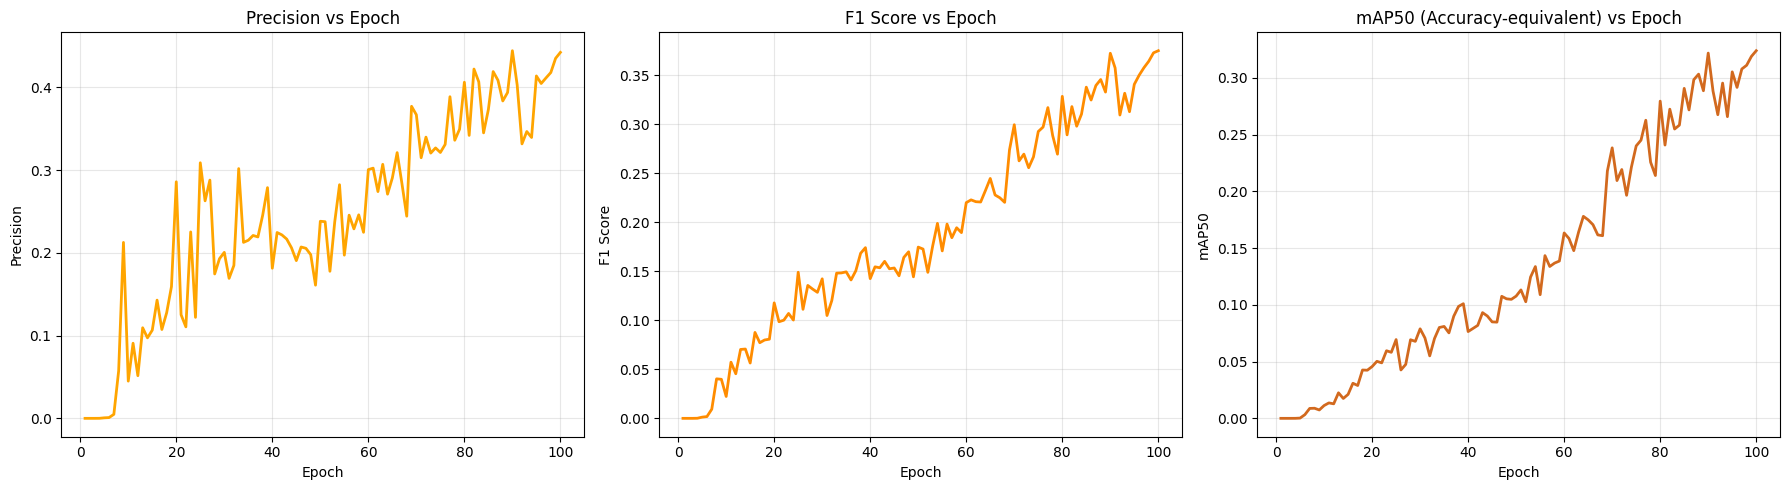


Final epoch metrics:
Precision: 0.4422
Recall:    0.3256
F1 Score:  0.3750
mAP50:     0.3240


In [ ]:
# Cell 2: Convert annotations, prepare YOLO dataset structure, finetune YOLOv11n, and plot metrics
import os
import glob
import random
import shutil
import xml.etree.ElementTree as ET
import yaml
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO

SRC_ROOT = path   # from kagglehub.dataset_download() in Cell 1
DST_ROOT = "/content/pcb_dataset"
IMG_TRAIN = f"{DST_ROOT}/images/train"
IMG_VAL   = f"{DST_ROOT}/images/val"
LBL_TRAIN = f"{DST_ROOT}/labels/train"
LBL_VAL   = f"{DST_ROOT}/labels/val"

for d in [IMG_TRAIN, IMG_VAL, LBL_TRAIN, LBL_VAL]:
    os.makedirs(d, exist_ok=True)

# ---------------------------------------------------------
# Step 1: Find all XML annotation files
# ---------------------------------------------------------
xml_files = glob.glob(f"{SRC_ROOT}/**/*.xml", recursive=True)
print(f"Found {len(xml_files)} XML annotation files")

if len(xml_files) == 0:
    raise RuntimeError(
        f"No XML files found under {SRC_ROOT}. "
        f"Check Cell 1's folder printout and confirm the dataset structure."
    )

# ---------------------------------------------------------
# Step 2: Parse XMLs, collect class names and boxes
# ---------------------------------------------------------
class_names = set()
parsed = []
for xf in xml_files:
    tree = ET.parse(xf)
    root = tree.getroot()
    img_name = root.find("filename").text
    img_path_candidates = glob.glob(f"{SRC_ROOT}/**/{img_name}", recursive=True)
    if not img_path_candidates:
        continue
    img_path = img_path_candidates[0]

    size = root.find("size")
    w = int(size.find("width").text)
    h = int(size.find("height").text)

    boxes = []
    for obj in root.findall("object"):
        cls = obj.find("name").text
        class_names.add(cls)
        bnd = obj.find("bndbox")
        xmin = float(bnd.find("xmin").text)
        ymin = float(bnd.find("ymin").text)
        xmax = float(bnd.find("xmax").text)
        ymax = float(bnd.find("ymax").text)
        boxes.append((cls, xmin, ymin, xmax, ymax))
    parsed.append((img_path, w, h, boxes))

class_names = sorted(class_names)
cls_to_id = {c: i for i, c in enumerate(class_names)}
print("Classes found:", class_names)
print(f"Total labeled images matched: {len(parsed)}")

# ---------------------------------------------------------
# Step 3: Train/val split (80/20)
# ---------------------------------------------------------
random.seed(42)
random.shuffle(parsed)
split_idx = int(0.8 * len(parsed))
train_set, val_set = parsed[:split_idx], parsed[split_idx:]

def write_yolo_labels(dataset, img_dst, lbl_dst):
    for img_path, w, h, boxes in dataset:
        img_name = os.path.basename(img_path)
        shutil.copy(img_path, os.path.join(img_dst, img_name))
        label_name = os.path.splitext(img_name)[0] + ".txt"
        with open(os.path.join(lbl_dst, label_name), "w") as f:
            for cls, xmin, ymin, xmax, ymax in boxes:
                cx = ((xmin + xmax) / 2) / w
                cy = ((ymin + ymax) / 2) / h
                bw = (xmax - xmin) / w
                bh = (ymax - ymin) / h
                f.write(f"{cls_to_id[cls]} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}\n")

write_yolo_labels(train_set, IMG_TRAIN, LBL_TRAIN)
write_yolo_labels(val_set, IMG_VAL, LBL_VAL)
print(f"Train: {len(train_set)} images | Val: {len(val_set)} images")

# ---------------------------------------------------------
# Step 4: Write data.yaml
# ---------------------------------------------------------
data_yaml = {
    "path": DST_ROOT,
    "train": "images/train",
    "val": "images/val",
    "nc": len(class_names),
    "names": class_names
}
yaml_path = f"{DST_ROOT}/data.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print("\ndata.yaml written:")
print(open(yaml_path).read())

# ---------------------------------------------------------
# Step 5: Finetune YOLOv11n
# ---------------------------------------------------------
model = YOLO("/content/yolo11n.pt")
results = model.train(
    data=yaml_path,
    epochs=100,
    imgsz=640,
    batch=16,
    patience=20,
    project="/content/runs/detect",
    name="train",
    exist_ok=True
)

print("\nTraining complete. Best weights at: /content/runs/detect/train/weights/best.pt")

# ---------------------------------------------------------
# Step 6: Extract Precision, F1, mAP50 from results.csv and plot vs Epoch
# ---------------------------------------------------------
results_csv = "/content/runs/detect/train/results.csv"
df = pd.read_csv(results_csv)
df.columns = [c.strip() for c in df.columns]  # strip whitespace from column names

epochs_axis = df["epoch"]
precision = df["metrics/precision(B)"]
recall = df["metrics/recall(B)"]
map50 = df["metrics/mAP50(B)"]  # closest detection equivalent to "accuracy"

f1 = (2 * precision * recall) / (precision + recall + 1e-16)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs_axis, precision, color="orange", linewidth=2)
axes[0].set_title("Precision vs Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Precision")
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_axis, f1, color="darkorange", linewidth=2)
axes[1].set_title("F1 Score vs Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1 Score")
axes[1].grid(alpha=0.3)

axes[2].plot(epochs_axis, map50, color="chocolate", linewidth=2)
axes[2].set_title("mAP50 (Accuracy-equivalent) vs Epoch")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("mAP50")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/content/pcb_metrics.png", dpi=150)
plt.show()

print("\nFinal epoch metrics:")
print(f"Precision: {precision.iloc[-1]:.4f}")
print(f"Recall:    {recall.iloc[-1]:.4f}")
print(f"F1 Score:  {f1.iloc[-1]:.4f}")
print(f"mAP50:     {map50.iloc[-1]:.4f}")

In [ ]:
# Cell 2 (v2): Convert annotations, prepare YOLO dataset, finetune YOLOv11s at high-res, plot metrics
import os
import glob
import random
import shutil
import xml.etree.ElementTree as ET
import yaml
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO

SRC_ROOT = path   # from kagglehub.dataset_download() in Cell 1
DST_ROOT = "/content/pcb_dataset"
IMG_TRAIN = f"{DST_ROOT}/images/train"
IMG_VAL   = f"{DST_ROOT}/images/val"
LBL_TRAIN = f"{DST_ROOT}/labels/train"
LBL_VAL   = f"{DST_ROOT}/labels/val"

for d in [IMG_TRAIN, IMG_VAL, LBL_TRAIN, LBL_VAL]:
    os.makedirs(d, exist_ok=True)

# ---------------------------------------------------------
# Step 1: Find all XML annotation files (skip re-parsing if already done)
# ---------------------------------------------------------
if not os.path.exists(f"{DST_ROOT}/data.yaml"):
    xml_files = glob.glob(f"{SRC_ROOT}/**/*.xml", recursive=True)
    print(f"Found {len(xml_files)} XML annotation files")

    if len(xml_files) == 0:
        raise RuntimeError(f"No XML files found under {SRC_ROOT}.")

    class_names = set()
    parsed = []
    for xf in xml_files:
        tree = ET.parse(xf)
        root = tree.getroot()
        img_name = root.find("filename").text
        img_path_candidates = glob.glob(f"{SRC_ROOT}/**/{img_name}", recursive=True)
        if not img_path_candidates:
            continue
        img_path = img_path_candidates[0]

        size = root.find("size")
        w = int(size.find("width").text)
        h = int(size.find("height").text)

        boxes = []
        for obj in root.findall("object"):
            cls = obj.find("name").text
            class_names.add(cls)
            bnd = obj.find("bndbox")
            xmin = float(bnd.find("xmin").text)
            ymin = float(bnd.find("ymin").text)
            xmax = float(bnd.find("xmax").text)
            ymax = float(bnd.find("ymax").text)
            boxes.append((cls, xmin, ymin, xmax, ymax))
        parsed.append((img_path, w, h, boxes))

    class_names = sorted(class_names)
    cls_to_id = {c: i for i, c in enumerate(class_names)}
    print("Classes found:", class_names)
    print(f"Total labeled images matched: {len(parsed)}")

    random.seed(42)
    random.shuffle(parsed)
    split_idx = int(0.8 * len(parsed))
    train_set, val_set = parsed[:split_idx], parsed[split_idx:]

    def write_yolo_labels(dataset, img_dst, lbl_dst):
        for img_path, w, h, boxes in dataset:
            img_name = os.path.basename(img_path)
            shutil.copy(img_path, os.path.join(img_dst, img_name))
            label_name = os.path.splitext(img_name)[0] + ".txt"
            with open(os.path.join(lbl_dst, label_name), "w") as f:
                for cls, xmin, ymin, xmax, ymax in boxes:
                    cx = ((xmin + xmax) / 2) / w
                    cy = ((ymin + ymax) / 2) / h
                    bw = (xmax - xmin) / w
                    bh = (ymax - ymin) / h
                    f.write(f"{cls_to_id[cls]} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}\n")

    write_yolo_labels(train_set, IMG_TRAIN, LBL_TRAIN)
    write_yolo_labels(val_set, IMG_VAL, LBL_VAL)
    print(f"Train: {len(train_set)} images | Val: {len(val_set)} images")

    data_yaml = {
        "path": DST_ROOT,
        "train": "images/train",
        "val": "images/val",
        "nc": len(class_names),
        "names": class_names
    }
    yaml_path = f"{DST_ROOT}/data.yaml"
    with open(yaml_path, "w") as f:
        yaml.dump(data_yaml, f, default_flow_style=False)
    print("\ndata.yaml written")
else:
    yaml_path = f"{DST_ROOT}/data.yaml"
    print("Dataset already prepared, reusing existing data.yaml")

# ---------------------------------------------------------
# Step 2: Finetune YOLOv11s (upgraded from nano) at higher resolution
# ---------------------------------------------------------
model = YOLO("yolo11s.pt")  # small variant — more capacity than nano, still fast

results = model.train(
    data=yaml_path,
    epochs=200,
    imgsz=1280,          # higher res — critical for tiny PCB defects
    batch=8,              # reduced from 16 since imgsz=1280 uses much more VRAM
    patience=40,
    lr0=0.001,
    optimizer="AdamW",
    box=10.0,              # increased box loss weight — prioritize precise localization
    cls=0.5,
    degrees=15.0,          # PCB defects are orientation-invariant, rotate freely
    fliplr=0.5,
    flipud=0.5,
    scale=0.6,
    mosaic=1.0,
    close_mosaic=15,
    project="/content/runs/detect",
    name="train_v2",
    exist_ok=True
)

print("\nTraining complete. Best weights at: /content/runs/detect/train_v2/weights/best.pt")

# ---------------------------------------------------------
# Step 3: Extract Precision, F1, mAP50 and plot vs Epoch
# ---------------------------------------------------------
results_csv = "/content/runs/detect/train_v2/results.csv"
df = pd.read_csv(results_csv)
df.columns = [c.strip() for c in df.columns]

epochs_axis = df["epoch"]
precision = df["metrics/precision(B)"]
recall = df["metrics/recall(B)"]
map50 = df["metrics/mAP50(B)"]
f1 = (2 * precision * recall) / (precision + recall + 1e-16)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(epochs_axis, precision, color="orange", linewidth=2)
axes[0].set_title("Precision vs Epoch"); axes[0].set_xlabel("Epoch"); axes[0].grid(alpha=0.3)
axes[1].plot(epochs_axis, f1, color="darkorange", linewidth=2)
axes[1].set_title("F1 Score vs Epoch"); axes[1].set_xlabel("Epoch"); axes[1].grid(alpha=0.3)
axes[2].plot(epochs_axis, map50, color="chocolate", linewidth=2)
axes[2].set_title("mAP50 vs Epoch"); axes[2].set_xlabel("Epoch"); axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/content/pcb_metrics_v2.png", dpi=150)
plt.show()

print("\nFinal epoch metrics:")
print(f"Precision: {precision.iloc[-1]:.4f}")
print(f"Recall:    {recall.iloc[-1]:.4f}")
print(f"F1 Score:  {f1.iloc[-1]:.4f}")
print(f"mAP50:     {map50.iloc[-1]:.4f}")

Dataset already prepared, reusing existing data.yaml
Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=10.0, cache=False, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/pcb_dataset/data.yaml, degrees=15.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train_v2, nbs=64, nms=False, opset=None, opt

In [1]:
# Cell 1: Download DsPCBSD+ dataset
import kagglehub

path = kagglehub.dataset_download("enisteper1/dataset-of-pcb-surface-defects-dspcbsd")
print("Path to dataset files:", path)

import os
for root, dirs, files in os.walk(path):
    print(root, "->", dirs, files[:5])

100%|██████████| 62.3M/62.3M [00:01<00:00, 46.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/enisteper1/dataset-of-pcb-surface-defects-dspcbsd/versions/4
/root/.cache/kagglehub/datasets/enisteper1/dataset-of-pcb-surface-defects-dspcbsd/versions/4 -> ['DsPCBSD+'] []
/root/.cache/kagglehub/datasets/enisteper1/dataset-of-pcb-surface-defects-dspcbsd/versions/4/DsPCBSD+ -> ['Data_YOLO'] ['data.yaml']
/root/.cache/kagglehub/datasets/enisteper1/dataset-of-pcb-surface-defects-dspcbsd/versions/4/DsPCBSD+/Data_YOLO -> ['labels', 'images'] []
/root/.cache/kagglehub/datasets/enisteper1/dataset-of-pcb-surface-defects-dspcbsd/versions/4/DsPCBSD+/Data_YOLO/labels -> ['val', 'train'] []
/root/.cache/kagglehub/datasets/enisteper1/dataset-of-pcb-surface-defects-dspcbsd/versions/4/DsPCBSD+/Data_YOLO/labels/val -> [] ['S_10376575.txt', 'Y_011488.txt', 'Y_011989.txt', 'S_11128632.txt', '0428716.txt']
/root/.cache/kagglehub/datasets/enisteper1/dataset-of-pcb-surface-defects-dspcbsd/versions/4/DsPCBSD+/Data_YOLO/labels/train -> [] ['S_11834071.t

In [2]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.2 MB/s eta 0:00:00


In [ ]:
# Cell 2: Locate YOLO-format data, build data.yaml, finetune YOLOv11n (25 epochs), plot metrics
import os
import glob
import shutil
import random
import yaml
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO
from IPython.display import display, Markdown

# ---------------------------------------------------------
# Step 1: Locate the Data_YOLO folder inside the downloaded dataset
# ---------------------------------------------------------
candidates = glob.glob(f"{path}/**/Data_YOLO", recursive=True)
if not candidates:
    candidates = [
        os.path.dirname(p) for p in glob.glob(f"{path}/**/images", recursive=True)
        if os.path.isdir(os.path.join(os.path.dirname(p), "labels"))
    ]

if not candidates:
    raise RuntimeError(
        f"Could not locate a Data_YOLO-style folder under {path}. "
        f"Check Cell 1's printout and manually set DATA_ROOT below."
    )

DATA_ROOT = candidates[0]
print("Using DATA_ROOT:", DATA_ROOT)

IMG_DIR = os.path.join(DATA_ROOT, "images")
LBL_DIR = os.path.join(DATA_ROOT, "labels")
print("Images dir contents (sample):", os.listdir(IMG_DIR)[:10])
print("Labels dir contents (sample):", os.listdir(LBL_DIR)[:10])

# ---------------------------------------------------------
# Step 2: Detect whether train/val split already exists
# ---------------------------------------------------------
has_split = os.path.isdir(os.path.join(IMG_DIR, "train")) and os.path.isdir(os.path.join(IMG_DIR, "val"))

if has_split:
    print("Existing train/val split detected — using as-is.")
    FINAL_ROOT = DATA_ROOT
else:
    print("No train/val split found — creating an 80/20 split.")
    FINAL_ROOT = "/content/pcb_dspcbsd_split"
    for d in ["images/train", "images/val", "labels/train", "labels/val"]:
        os.makedirs(os.path.join(FINAL_ROOT, d), exist_ok=True)

    all_images = sorted(glob.glob(os.path.join(IMG_DIR, "*.*")))
    all_images = [f for f in all_images if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))]
    random.seed(42)
    random.shuffle(all_images)
    split_idx = int(0.8 * len(all_images))
    train_imgs, val_imgs = all_images[:split_idx], all_images[split_idx:]

    def copy_split(img_list, subset):
        for img_path in img_list:
            base = os.path.splitext(os.path.basename(img_path))[0]
            lbl_path = os.path.join(LBL_DIR, base + ".txt")
            shutil.copy(img_path, os.path.join(FINAL_ROOT, "images", subset, os.path.basename(img_path)))
            if os.path.exists(lbl_path):
                shutil.copy(lbl_path, os.path.join(FINAL_ROOT, "labels", subset, base + ".txt"))
            else:
                open(os.path.join(FINAL_ROOT, "labels", subset, base + ".txt"), "w").close()

    copy_split(train_imgs, "train")
    copy_split(val_imgs, "val")
    print(f"Train: {len(train_imgs)} images | Val: {len(val_imgs)} images")

# ---------------------------------------------------------
# Step 3: Class names — VERIFY against any bundled classes.txt/notes.json
# ---------------------------------------------------------
class_names_file = glob.glob(f"{path}/**/classes.txt", recursive=True)
if class_names_file:
    with open(class_names_file[0]) as f:
        class_names = [line.strip() for line in f if line.strip()]
    print("Loaded class names from bundled classes.txt:", class_names)
else:
    class_names = [
        "short", "spur", "spurious_copper", "open",
        "mouse_bite", "hole_breakout", "conductor_scratch",
        "conductor_foreign_object", "base_material_foreign_object"
    ]
    print("WARNING: no classes.txt found — using paper-order guess. Verify against dataset docs:")
    print(class_names)

# ---------------------------------------------------------
# Step 4: Write data.yaml
# ---------------------------------------------------------
data_yaml = {
    "path": FINAL_ROOT,
    "train": "images/train",
    "val": "images/val",
    "nc": len(class_names),
    "names": class_names
}
yaml_path = f"{FINAL_ROOT}/data.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print("\ndata.yaml written:")
print(open(yaml_path).read())

# ---------------------------------------------------------
# Step 5: Train YOLOv11n — 25 epochs
# ---------------------------------------------------------
MODEL_NAME = "/content/yolo11n.pt"
EPOCHS = 25
IMG_SIZE = 640
BATCH_SIZE = 16
DEVICE = 0
PROJECT_NAME = "/content/runs/detect"
RUN_NAME = "dspcbsd_yolo11n_25ep"
SEED = 42

display(Markdown("## Training YOLOv11n on DsPCBSD+ (25 epochs)"))

model = YOLO(MODEL_NAME)

results = model.train(
    data=yaml_path,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    workers=4,
    patience=20,
    project=PROJECT_NAME,
    name=RUN_NAME,
    pretrained=True,
    optimizer="AdamW",
    lr0=1e-3,
    cos_lr=True,
    close_mosaic=10,
    val=True,
    seed=SEED,
)

print(f"\nTraining complete. Best weights at: {PROJECT_NAME}/{RUN_NAME}/weights/best.pt")

# ---------------------------------------------------------
# Step 6: Plot Precision, F1, mAP50 vs Epoch
# ---------------------------------------------------------
results_csv = f"{PROJECT_NAME}/{RUN_NAME}/results.csv"
df = pd.read_csv(results_csv)
df.columns = [c.strip() for c in df.columns]

epochs_axis = df["epoch"]
precision = df["metrics/precision(B)"]
recall = df["metrics/recall(B)"]
map50 = df["metrics/mAP50(B)"]
f1 = (2 * precision * recall) / (precision + recall + 1e-16)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs_axis, precision, color="orange", linewidth=2)
axes[0].set_title("Precision vs Epoch"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Precision"); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_axis, f1, color="darkorange", linewidth=2)
axes[1].set_title("F1 Score vs Epoch"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("F1 Score"); axes[1].grid(alpha=0.3)

axes[2].plot(epochs_axis, map50, color="chocolate", linewidth=2)
axes[2].set_title("mAP50 vs Epoch"); axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("mAP50"); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/content/dspcbsd_metrics_25ep.png", dpi=150)
plt.show()

print("\nFinal epoch metrics:")
print(f"Precision: {precision.iloc[-1]:.4f}")
print(f"Recall:    {recall.iloc[-1]:.4f}")
print(f"F1 Score:  {f1.iloc[-1]:.4f}")
print(f"mAP50:     {map50.iloc[-1]:.4f}")

Using DATA_ROOT: /root/.cache/kagglehub/datasets/enisteper1/dataset-of-pcb-surface-defects-dspcbsd/versions/4/DsPCBSD+/Data_YOLO
Images dir contents (sample): ['val', 'train']
Labels dir contents (sample): ['val', 'val.cache', 'train.cache', 'train']
Existing train/val split detected — using as-is.
['short', 'spur', 'spurious_copper', 'open', 'mouse_bite', 'hole_breakout', 'conductor_scratch', 'conductor_foreign_object', 'base_material_foreign_object']

data.yaml written:
names:
- short
- spur
- spurious_copper
- open
- mouse_bite
- hole_breakout
- conductor_scratch
- conductor_foreign_object
- base_material_foreign_object
nc: 9
path: /root/.cache/kagglehub/datasets/enisteper1/dataset-of-pcb-surface-defects-dspcbsd/versions/4/DsPCBSD+/Data_YOLO
train: images/train
val: images/val



## Training YOLOv11n on DsPCBSD+ (25 epochs)

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/root/.cache/kagglehub/datasets/enisteper1/dataset-of-pcb-surface-defects-dspcbsd/versions/4/DsPCBSD+/Data_YOLO/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name